# Projet Red Line - Airbnb Montréal
## Phase 5 : Analyse de données avec Python
**Dataset: ** Inside Airbnb - listings.csv x reviews.csv
**Outils: ** pandas, matplotlib, seaborn

## 1. Configuration
Importation des librairies nécessaires pour la manipulation et la visualisation des données.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Chargement des données
Chargement de listings.csv (9 550 logements) et reviews.csv (255 851 avis)
depuis Inside Airbnb — Montréal, Québec, Canada.
Source : insideairbnb.com/get-the-data

In [2]:
listings = pd.read_csv("listings.csv")
reviews = pd.read_csv("reviews.csv")
print("Listings :", listings.shape)
print("Reviews :", reviews.shape)

Listings : (9550, 18)
Reviews : (403093, 2)


In [3]:
listings.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,29059,Lovely studio Quartier Latin,125031,Maryline,NaN,Ville-Marie,45.51939,-73.56482,Entire home/apt,134.0,31,499,2025-09-01,2.69,2,312,31,"Quebec - Registration number<br />267153, expi..."
1,29061,Maison historique - Quartier Latin,125031,Maryline,NaN,Ville-Marie,45.51929,-73.56493,Entire home/apt,253.0,2,168,2025-09-02,1.02,2,332,20,"Quebec - Registration number<br />267153, expi..."
2,38118,Beautiful room with a balcony in front of a parc,163569,M.,NaN,Ville-Marie,45.52699,-73.55840,Private room,47.0,31,17,2024-08-31,0.10,3,322,0,NaN
3,50479,L'Arcade Douce,231694,Noemie,NaN,Rosemont-La Petite-Patrie,45.54157,-73.60737,Entire home/apt,156.0,3,349,2025-09-12,1.92,2,29,56,"Quebec - Registration number<br />271530, expi..."
4,66247,Modern Loft Next To Basilica Notre Dame In Old...,318040,Mohamed,NaN,Ville-Marie,45.50584,-73.55602,Entire home/apt,146.0,31,588,2025-09-03,3.28,4,38,84,"Quebec - Registration number<br />314544, expi..."


In [4]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9550 entries, 0 to 9549
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              9550 non-null   int64  
 1   name                            9550 non-null   object 
 2   host_id                         9550 non-null   int64  
 3   host_name                       9549 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   9550 non-null   object 
 6   latitude                        9550 non-null   float64
 7   longitude                       9550 non-null   float64
 8   room_type                       9550 non-null   object 
 9   price                           8483 non-null   float64
 10  minimum_nights                  9550 non-null   int64  
 11  number_of_reviews               9550 non-null   int64  
 12  last_review                     76

In [5]:
listings.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,9.550000e+03,9.550000e+03,0.0,9550.000000,9550.000000,8483.000000,9550.000000,9550.000000,7635.000000,9550.000000,9550.000000,9550.000000
mean,7.898922e+17,2.508675e+08,NaN,45.511957,-73.588266,180.857715,26.074869,42.208691,1.735713,16.421152,202.915288,11.937382
std,5.618820e+17,2.247413e+08,NaN,0.033020,0.048211,495.875569,35.488806,78.621314,2.152446,28.977474,118.555774,21.591958
min,2.905900e+04,2.319000e+03,NaN,45.405470,-73.947310,12.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,5.011358e+07,3.414866e+07,NaN,45.494880,-73.600045,81.000000,2.000000,1.000000,0.260000,1.000000,99.000000,0.000000
50%,9.433531e+17,1.955014e+08,NaN,45.511380,-73.575750,125.000000,31.000000,10.000000,0.970000,5.000000,219.000000,2.000000
75%,1.281169e+18,4.646616e+08,NaN,45.528120,-73.562564,192.000000,31.000000,47.000000,2.705000,16.000000,315.000000,17.000000
max,1.512003e+18,7.181658e+08,NaN,45.699950,-73.481630,26724.000000,730.000000,986.000000,50.000000,141.000000,365.000000,427.000000


In [6]:
listings.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,1
neighbourhood_group,9550
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,1067


## 3. Nettoyage des données
- Suppression de `neighbourhood_group` (100% valeurs manquantes)
- Suppression de 1 067 logements sans prix
- Conversion de la colonne date en format datetime
- Dataset final : 8 483 logements × 17 colonnes

In [9]:
listings = listings.drop(columns=['neighbourhood_group'])

KeyError: "['neighbourhood_group'] not found in axis"

In [10]:
listings = listings.dropna(subset=['price'])

In [11]:
print("Lignes restantes :", len(listings))
print("Colonnes restantes :", len(listings.columns))

Lignes restantes : 8483
Colonnes restantes : 17


In [ ]:
listings.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,8.483000e+03,8.483000e+03,8483.000000,8483.000000,8483.000000,8483.000000,8483.000000,6791.000000,8483.000000,8483.000000,8483.000000
mean,7.971458e+17,2.539201e+08,45.511642,-73.588796,180.857715,25.267594,43.636567,1.805391,16.154309,221.358953,12.451491
std,5.634798e+17,2.258978e+08,0.033103,0.049529,495.875569,32.989439,80.464203,2.139715,28.208192,107.124098,21.422152
min,2.905900e+04,2.319000e+03,45.405470,-73.947310,12.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,5.077570e+07,3.440566e+07,45.494730,-73.601535,81.000000,2.000000,1.000000,0.280000,1.000000,136.000000,0.000000
50%,9.457955e+17,1.955014e+08,45.510891,-73.575559,125.000000,31.000000,10.000000,1.000000,5.000000,235.000000,2.000000
75%,1.298547e+18,4.649803e+08,45.527493,-73.562420,192.000000,31.000000,51.000000,2.830000,16.000000,322.000000,18.000000
max,1.512003e+18,7.181658e+08,45.699950,-73.481630,26724.000000,365.000000,986.000000,50.000000,141.000000,365.000000,427.000000


## 4. Analyse 1 — Prix moyen par quartier
**Question :** Quel est le prix moyen par nuit selon le quartier ?
**Résultat :** Mont-Royal en tête à 347$/nuit, suivi de Hampstead à 305$/nuit.

In [13]:
prix_quartier = (listings.groupby('neighbourhood')['price']
                 .mean()
                 .round(2)
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())

prix_quartier.columns = ['Quartier', 'Prix moyen']
print(prix_quartier)

                        Quartier  Prix moyen
0                     Mont-Royal      347.36
1                      Hampstead      305.67
2  L'Île-Bizard-Sainte-Geneviève      272.57
3                      Outremont      245.03
4                    Baie-d'Urfé      234.17
5                         Dorval      232.67
6          Le Plateau-Mont-Royal      225.63
7                    Ville-Marie      199.53
8  Mercier-Hochelaga-Maisonneuve      194.90
9                   Le Sud-Ouest      192.89


/tmp/ipykernel_40704/953909410.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prix_quartier, x='Prix moyen', y='Quartier', palette='Reds_r')


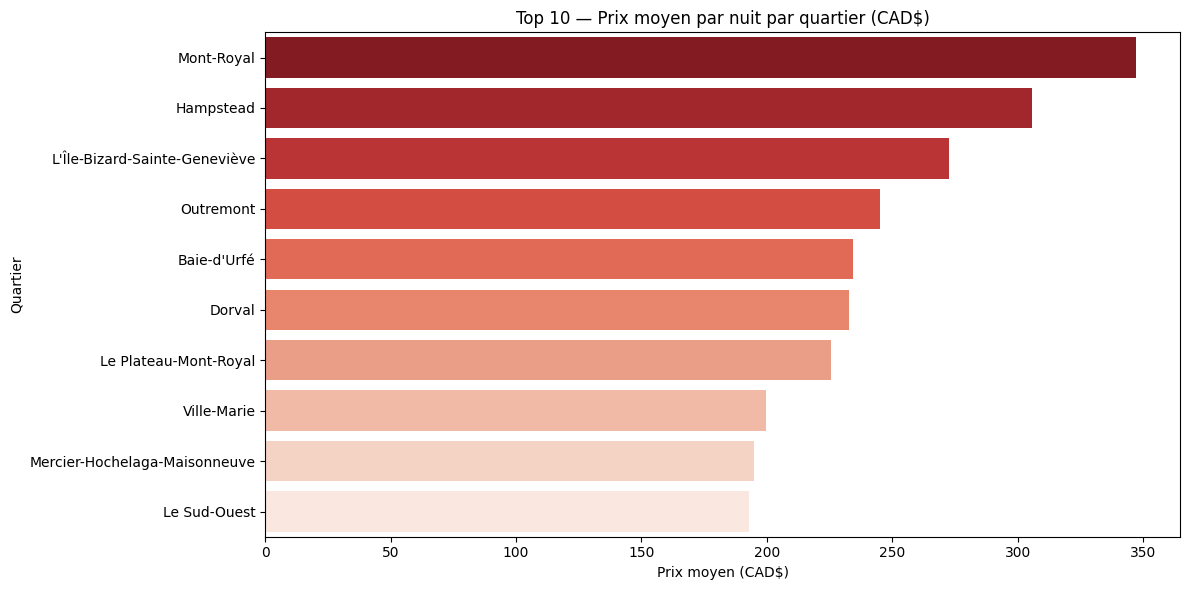

In [14]:
plt.figure(figsize=(12, 6))

# barh() = bar horizontal — plus lisible pour les noms de quartiers longs
# x = valeurs numériques, y = catégories
sns.barplot(data=prix_quartier, x='Prix moyen', y='Quartier', palette='Reds_r')

# Titres et labels
plt.title('Top 10 — Prix moyen par nuit par quartier (CAD$)')
plt.xlabel('Prix moyen (CAD$)')
plt.ylabel('Quartier')

# Affiche le graphique
plt.tight_layout()
plt.show()

## 5. Analyse 2 — Saisonnalité des avis (2022-2025)
**Question :** Quels mois concentrent le plus d'avis ?
**Résultat :** Pic en août — confirme la saison touristique estivale de Montréal.

In [15]:
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')

reviews['mois'] = reviews['date'].dt.month
reviews['annee'] = reviews['date'].dt.year

print(reviews[['date', 'mois', 'annee']].head(10))

        date  mois  annee
0 2010-06-20     6   2010
1 2010-07-02     7   2010
2 2010-07-05     7   2010
3 2011-07-20     7   2011
4 2011-07-26     7   2011
5 2011-08-14     8   2011
6 2011-09-26     9   2011
7 2011-10-09    10   2011
8 2011-10-16    10   2011
9 2011-11-05    11   2011


In [25]:
from pandas.core import groupby
reviews_recent = reviews[reviews['annee'].between(2022,2025)]
saisonnalite = (reviews_recent
                .groupby('mois')
                .size()
                .reset_index(name='nb_avis'))
mois_noms = {1:'Jan', 2:'Fév', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Jun',
             7:'Jul', 8:'Aoû', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Déc'}

saisonnalite['mois'] = saisonnalite['mois'].map(mois_noms)
print(saisonnalite)

   mois  nb_avis
0   Jan    16743
1   Fév    16779
2   Mar    20389
3   Avr    23212
4   Mai    29318
5   Jun    32674
6   Jul    37511
7   Aoû    41341
8   Sep    26078
9   Oct    21996
10  Nov    16689
11  Déc    16731


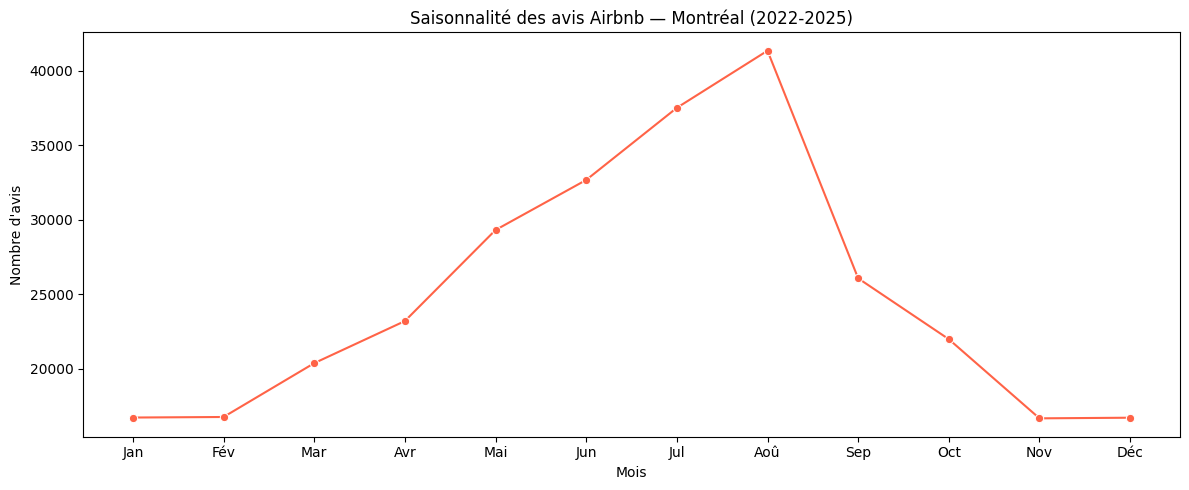

In [29]:
# plt.figure() — crée une nouvelle "toile" vide pour dessiner
# figsize=(12,5) — largeur 12 pouces, hauteur 5 pouces
plt.figure(figsize=(12, 5))

# sns.lineplot() — dessine une courbe
# data= — le DataFrame source
# x= — colonne pour l'axe horizontal (les mois)
# y= — colonne pour l'axe vertical (nb d'avis)
# marker='o' — ajoute un point visible à chaque mois
# color= — couleur de la courbe
sns.lineplot(data=saisonnalite,
             x='mois',
             y='nb_avis',
             marker='o',
             color='tomato')

# plt.title() — titre principal du graphique
plt.title('Saisonnalité des avis Airbnb — Montréal (2022-2025)')

# plt.xlabel() / plt.ylabel() — labels des axes
plt.xlabel('Mois')
plt.ylabel("Nombre d'avis")

# plt.tight_layout() — ajuste automatiquement les marges
# évite que les labels soient coupés sur les bords
plt.tight_layout()

# plt.show() — affiche le graphique
# sans ça Colab n'affiche rien
plt.show()

## 6. Analyse 3 — Corrélation prix vs nombre d'avis
**Question :** Les logements plus chers reçoivent-ils plus d'avis ?
**Résultat :** Corrélation positive légère — les logements chers tendent à recevoir plus d'avis.

In [35]:
nb_avis = (reviews
           .groupby('listing_id')
           .size()
           .reset_index(name='nb_avis_reviews'))

df_merge = pd.merge(left=listings,
                    right=nb_avis,
                    left_on='id',
                    right_on='listing_id',
                    how='left')

print(df_merge)

df_merge['nb_avis_reviews'] = df_merge['nb_avis_reviews'].fillna(0)


print(df_merge[['name', 'neighbourhood', 'price', 'nb_avis_reviews']].head(10))

                       id                                               name  \
0                   29059                       Lovely studio Quartier Latin   
1                   29061                 Maison historique - Quartier Latin   
2                   38118  Beautiful room  with a balcony in front of a parc   
3                   50479                                     L'Arcade Douce   
4                   66247  Modern Loft Next To Basilica Notre Dame In Old...   
...                   ...                                                ...   
8478  1511844864103257216             Cozy Room Steps from Metro and Dinning   
8479  1511850984099195063             Cozy room Steps from Metro And dinning   
8480  1511857608100670257             Cozy room Steps from Metro and Dinning   
8481  1511906353702828580                 Unique 1+1BDR in Central of DT MTL   
8482  1512002663328104707  Convenient unit downtown next to Mt-Royal & Mc...   

        host_id  host_name             

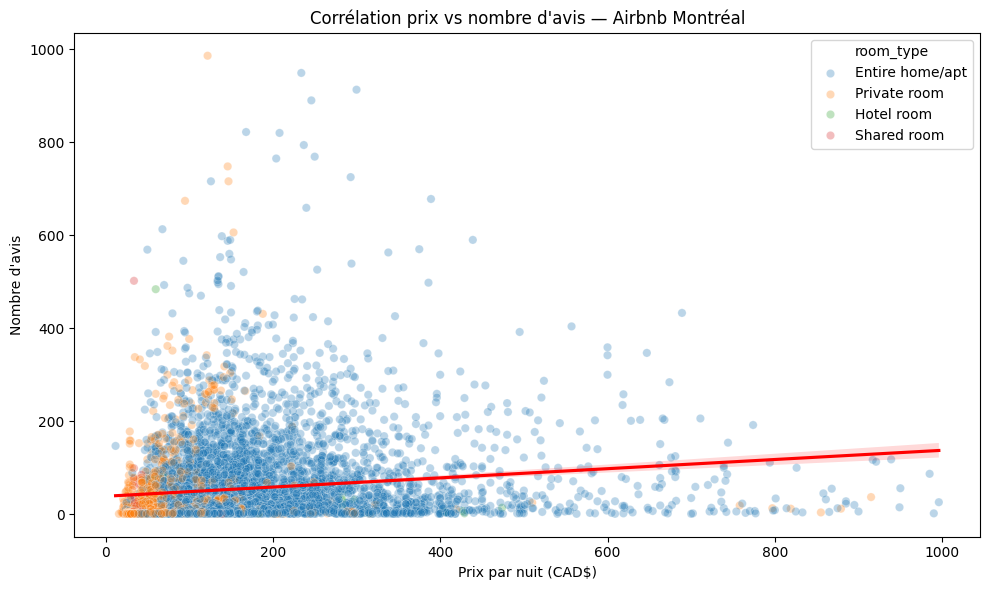

Coefficient de corrélation : 0.02


In [36]:
# On filtre les outliers — les prix > 1000$ faussent le graphique
# visuellement car ils étirent l'axe X et écrasent les autres points
# .query() filtre les lignes selon une condition — comme WHERE en SQL
df_plot = df_merge.query('price < 1000 and nb_avis_reviews > 0')

plt.figure(figsize=(10, 6))

# sns.scatterplot() — nuage de points
# alpha=0.3 — transparence des points (0=invisible, 1=opaque)
# avec 8000+ points, la transparence permet de voir
# où les points se concentrent
# hue= — colore les points selon une 3e variable
sns.scatterplot(data=df_plot,
                x='price',
                y='nb_avis_reviews',
                alpha=0.3,
                hue='room_type')

# sns.regplot() — ajoute une droite de régression
# qui montre la tendance générale
# scatter=False — on dessine seulement la droite, pas les points
# color='red' — couleur de la droite
sns.regplot(data=df_plot,
            x='price',
            y='nb_avis_reviews',
            scatter=False,
            color='red')

plt.title('Corrélation prix vs nombre d\'avis — Airbnb Montréal')
plt.xlabel('Prix par nuit (CAD$)')
plt.ylabel("Nombre d'avis")
plt.tight_layout()
plt.show()

# Calculer le coefficient de corrélation
# .corr() retourne un nombre entre -1 et 1
# -1 = corrélation négative parfaite
#  0 = aucune corrélation
# +1 = corrélation positive parfaite
correlation = df_merge['price'].corr(df_merge['nb_avis_reviews'])
print(f"Coefficient de corrélation : {correlation:.2f}")

## 7. Analyse 4 — Top hôtes par nombre de logements
**Question :** Quels hôtes dominent le marché Airbnb Montréal ?
**Résultat :** Alex domine avec 117 logements — présence claire d'opérateurs professionnels.

In [37]:
top_hotes = (df_merge
             .groupby('host_id')
             .agg(
                 nb_logements=('name', 'count'),
                 host_name=('host_name', 'first')
             )
             .sort_values('nb_logements', ascending=False)
             .head(15)
             .reset_index())

print(top_hotes)

      host_id  nb_logements          host_name
0   117827514           117               Alex
1   195501369           116              Julio
2   195649860            86     Jean-Christoph
3     4365710            81            Tristan
4   434955825            76          Gabrielle
5      487327            71              Louis
6     9818417            65              Andre
7    66340481            54             Daniel
8   224865057            47  Sonder (Montreal)
9   306041574            47       Jorge Arturo
10   73995257            45             Barwir
11  219345292            44       Unique Stays
12  146743514            43              Frits
13  408542876            40       Robert David
14  594097140            36              Kevin


/tmp/ipykernel_40704/4080203571.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hotes,


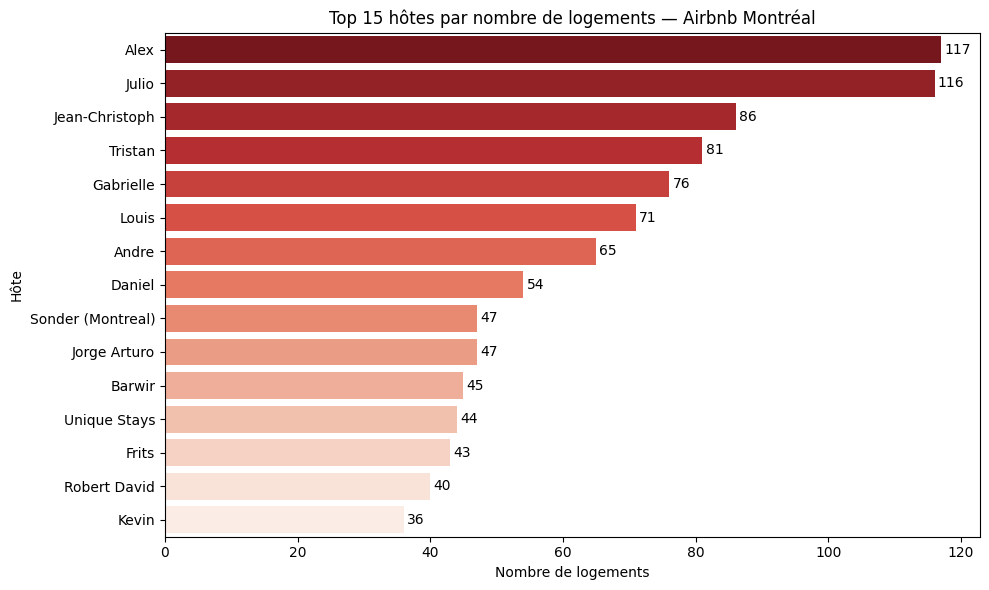

In [38]:
plt.figure(figsize=(10, 6))

# sns.barplot() — graphique à barres
# x= — valeurs numériques (nb logements)
# y= — catégories (noms des hôtes)
# palette='Reds_r' — dégradé rouge décroissant
#   'Reds' = du clair au foncé
#   'Reds_r' = inversé, du foncé au clair
#   le _r signifie 'reversed'
sns.barplot(data=top_hotes,
            x='nb_logements',
            y='host_name',
            palette='Reds_r')

# Ajouter les valeurs sur chaque barre
# .patches — accède à chaque barre du graphique
# .get_width() — récupère la largeur de la barre = la valeur
# plt.text() — écrit du texte à une position précise
for bar in plt.gca().patches:
    plt.text(
        bar.get_width() + 0.5,    # position X — juste après la barre
        bar.get_y() + bar.get_height()/2,  # position Y — centre de la barre
        f'{int(bar.get_width())}',  # texte — la valeur entière
        va='center',               # alignement vertical centré
        fontsize=10
    )

plt.title('Top 15 hôtes par nombre de logements — Airbnb Montréal')
plt.xlabel('Nombre de logements')
plt.ylabel('Hôte')
plt.tight_layout()
plt.show()

## 8. Analyse 5 — Distribution des prix par type de logement
**Question :** Comment les prix varient-ils selon le type de logement ?
**Résultat :** Les chambres d'hôtel sont les plus chères, les chambres partagées les moins chères.

/tmp/ipykernel_40704/1185991543.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge.query('price < 500'),


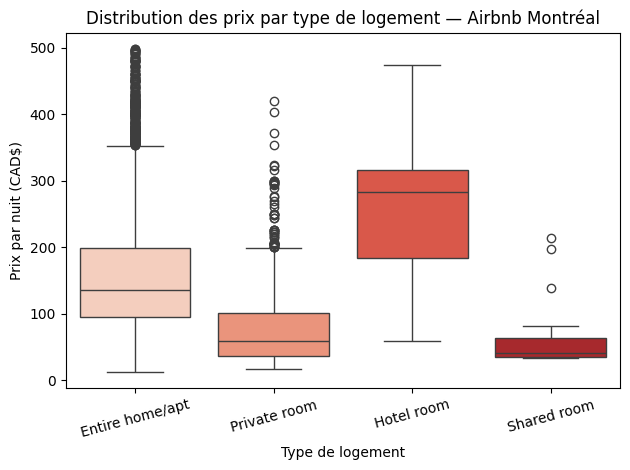

In [40]:
stats_room = (df_merge
              .groupby('room_type')
              .agg(
                  prix_moyen=('price', 'mean'),
                  prix_median=('price', 'median'),
                  nb_logements=('price', 'count')
              )
              .round(2)
              .reset_index()
              .sort_values('prix_moyen', ascending=False))


sns.boxplot(data=df_merge.query('price < 500'),
            x='room_type',
            y='price',
            palette='Reds')

plt.title('Distribution des prix par type de logement — Airbnb Montréal')
plt.xlabel('Type de logement')
plt.ylabel('Prix par nuit (CAD$)')

# rotation des labels X pour qu'ils soient lisibles
# plt.xticks() accède aux labels de l'axe X
# rotation=15 — incline les textes de 15 degrés
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
## Conclusion
Cette analyse de 8 483 logements Airbnb à Montréal révèle :
1. **Mont-Royal** est le quartier le plus cher à 347$/nuit
2. **Août** est le pic de la saison avec le plus grand volume d'avis
3. **Corrélation positive** entre le prix et le nombre d'avis
4. **Alex** domine avec 117 logements — un marché professionnel existe
5. **Les chambres d'hôtel** commandent les prix les plus élevés par type

**Outils utilisés :** Python, pandas, matplotlib, seaborn
**Dataset :** Inside Airbnb — Montréal (septembre 2025)
**Projet :** Red Line — https://github.com/JerryHeritian/red-line